# Notebook 4 — Sentiment Analysis (Classical → Neural → Transformers → ABSA)

In previous notebooks we built:
- a cleaned Persian text pipeline
- a TF‑IDF doctor retriever

In this notebook, we move to a new task:

> **Sentiment Analysis**: classify each patient review as **Positive / Neutral / Negative**.

We will keep this notebook **teachable** and **self-contained**:
- We only use the dataset exported by previous notebooks.
- We can run everything in a small **Demo Mode** (fast, classroom-friendly).
- The same code can also run on the full project dataset.



## Part 0 — Setup & Data Loading

### Dataset used in this notebook

We load the file produced by the earlier notebooks:

**`comments_for_tfidf_retriever_sentiment.csv`**

It contains one row per patient review, with these columns:

- `doctor_id`
- `final_preprocessed_text`  (tokenized text, mostly useful for retrieval)
- `text_step04`              (cleaned Persian text, readable, best for sentiment)
- `rate`                     (1–5 stars; *not* a perfect sentiment label)
- `label`                    (raw label from source; may contain placeholder negatives)
- `is_placeholder_negative`  (e.g., text = "عدم رضایت")

### Our sentiment text column

For sentiment modeling we will use:
- **`text_step04`** as the main input text (human-readable, still has sentiment words)

In [1]:
# Part 0.2 — Imports
# ----------------------------

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.25
})

print("Imports OK")

Imports OK


In [5]:
# ----------------------------
# Part 0.3 — Configuration
# ----------------------------
from pathlib import Path

MODE = "demo"   # "demo" (fast) or "full" (project-scale)
DEMO_N = 2000   # used only in demo mode
PATH = r"C:\Mohsen Folder\Ai Bootcamp\Ai Bootcamp\data\raw\Training & Education Data\NLP"


DATA_PATH = Path(os.path.join(PATH, "comments_for_tfidf_retriever_sentiment.csv"))

OUT_DIR = Path(os.path.join(PATH, "processed_data/notebook04_sentiment"))

MODEL_DIR = Path(os.path.join(PATH, "models/notebook04_sentiment"))

OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"MODE     = {MODE}")
print(f"DEMO_N   = {DEMO_N}")
print(f"DATA     = {DATA_PATH}")
print(f"OUT_DIR  = {OUT_DIR}")
print(f"MODEL_DIR= {MODEL_DIR}")

MODE     = demo
DEMO_N   = 2000
DATA     = C:\Mohsen Folder\Ai Bootcamp\Ai Bootcamp\data\raw\Training & Education Data\NLP\comments_for_tfidf_retriever_sentiment.csv
OUT_DIR  = C:\Mohsen Folder\Ai Bootcamp\Ai Bootcamp\data\raw\Training & Education Data\NLP\processed_data\notebook04_sentiment
MODEL_DIR= C:\Mohsen Folder\Ai Bootcamp\Ai Bootcamp\data\raw\Training & Education Data\NLP\models\notebook04_sentiment


In [ ]:
# ----------------------------
# Part 0.4 — Load the dataset
# ----------------------------

df = pd.read_csv(DATA_PATH, keep_default_na=False)

# Basic type fixes
df["doctor_id"] = df["doctor_id"].astype(str)
df["text_step04"] = df["text_step04"].astype(str)
df["final_preprocessed_text"] = df["final_preprocessed_text"].astype(str)

In [ ]:
df.head()

,doctor_id,final_preprocessed_text,text_step04,rate,label,date,tok_all_count,tok_nostop_count,is_placeholder_negative
0,100246,حاذق,بسیار حاذق,5.0,1,۱۴۰۳/۰۸/۰۴,2,1,False
1,100246,زگیل ناخن درمانم,زگیل زیر ناخن تحت درمانم,5.0,1,۱۴۰۰/۰۲/۰۶,5,3,False
2,100246,درود تشخیص درست خارش بدن ودرمان,درود تشخیص درست خارش بدن ودرمان عالی,5.0,1,۱۴۰۴/۰۹/۲۸,7,6,False
3,100246,دقت حوصله,بسیار با دقت و با حوصله,5.0,1,۱۴۰۴/۰۹/۲۷,5,2,False
4,100246,تشخیص ممنون,تشخیص ایشان خیلی خوب بود ممنون,5.0,1,۱۴۰۴/۰۵/۲۷,6,2,False


In [ ]:
df.rate.unique()

array([5. , 2.5, 0. ])

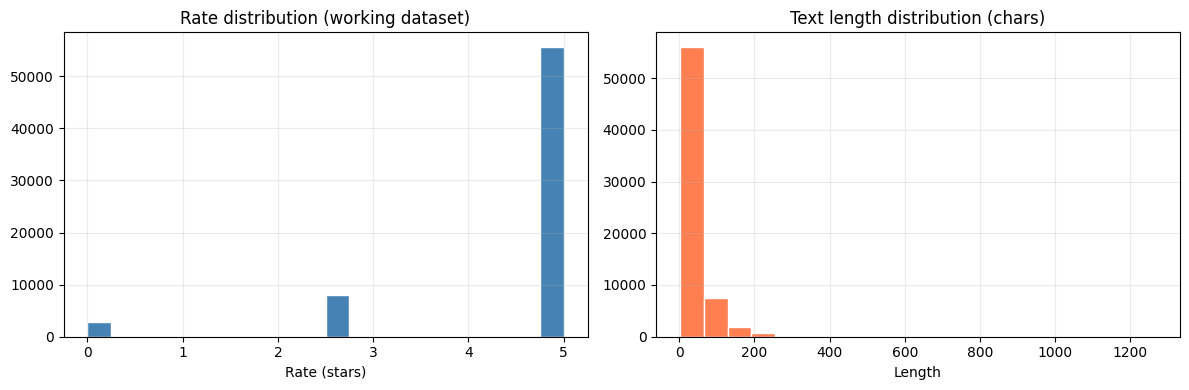

Example texts:
- عالیه بود کارشون
- خوش‌برخورد و با حوصله
- بی‌نظیر ایشون تشخیص نادری رودادند و خیلی سریع درمان شدم ممنونم از دلسوزی و لطفشون دکتر باسواد و دلسوز
- تحت درمان هستم
- بسیار دکتر عالی و کار بلد واقعا از خدماتشون ممنونم پیشنهاد می‌کنم مراجع کنید


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["rate"].dropna().hist(bins=20, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Rate distribution (working dataset)")
axes[0].set_xlabel("Rate (stars)")

text_len = df["text_step04"].astype(str).str.len()
text_len.hist(bins=20, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Text length distribution (chars)")
axes[1].set_xlabel("Length")

plt.tight_layout()
plt.show()

print("Example texts:")
for t in df["text_step04"].sample(5, random_state=SEED).tolist():
    print("-", t[:120])

In [ ]:
len(df)

66464

In [ ]:
df["rate_num"] = pd.to_numeric(df.get("rate", np.nan))

In [ ]:
# Convert rate to numeric (may contain empty strings)
df["rate_num"] = pd.to_numeric(df.get("rate", np.nan), errors="coerce")
df.head()

,doctor_id,final_preprocessed_text,text_step04,rate,label,date,tok_all_count,tok_nostop_count,is_placeholder_negative,rate_num
0,100246,حاذق,بسیار حاذق,5.0,1,۱۴۰۳/۰۸/۰۴,2,1,False,5.0
1,100246,زگیل ناخن درمانم,زگیل زیر ناخن تحت درمانم,5.0,1,۱۴۰۰/۰۲/۰۶,5,3,False,5.0
2,100246,درود تشخیص درست خارش بدن ودرمان,درود تشخیص درست خارش بدن ودرمان عالی,5.0,1,۱۴۰۴/۰۹/۲۸,7,6,False,5.0
3,100246,دقت حوصله,بسیار با دقت و با حوصله,5.0,1,۱۴۰۴/۰۹/۲۷,5,2,False,5.0
4,100246,تشخیص ممنون,تشخیص ایشان خیلی خوب بود ممنون,5.0,1,۱۴۰۴/۰۵/۲۷,6,2,False,5.0


,doctor_id,final_preprocessed_text,text_step04,rate,label,date,tok_all_count,tok_nostop_count,is_placeholder_negative,rate_num
29,100246,رضایت,عدم رضایت,0.0,-1,۱۴۰۴/۱۱/۲۸,2,1,True,0.0
33,100246,رضایت,عدم رضایت,0.0,-1,۱۴۰۳/۰۳/۲۳,2,1,True,0.0
40,100246,رضایت,عدم رضایت,0.0,-1,۱۴۰۴/۱۰/۱۶,2,1,True,0.0
50,100246,رضایت,عدم رضایت,0.0,-1,۱۴۰۲/۱۲/۱۵,2,1,True,0.0
55,100246,رضایت,عدم رضایت,0.0,-1,۱۴۰۳/۱۲/۰۶,2,1,True,0.0
...,...,...,...,...,...,...,...,...,...,...
65869,339757,رضایت,عدم رضایت,0.0,-1,۱۴۰۴/۱۱/۲۵,2,1,True,0.0
65888,340351,رضایت,عدم رضایت,0.0,-1,۱۴۰۴/۰۸/۲۵,2,1,True,0.0
66061,340754,رضایت,عدم رضایت,0.0,-1,۱۴۰۵/۰۲/۰۲,2,1,True,0.0
66102,341287,رضایت,عدم رضایت,0.0,-1,۱۴۰۴/۱۱/۰۷,2,1,True,0.0


In [ ]:
df[df["is_placeholder_negative"]==True]

,doctor_id,final_preprocessed_text,text_step04,rate,label,date,tok_all_count,tok_nostop_count,is_placeholder_negative,rate_num
29,100246,رضایت,عدم رضایت,0.0,-1,۱۴۰۴/۱۱/۲۸,2,1,True,0.0
33,100246,رضایت,عدم رضایت,0.0,-1,۱۴۰۳/۰۳/۲۳,2,1,True,0.0
40,100246,رضایت,عدم رضایت,0.0,-1,۱۴۰۴/۱۰/۱۶,2,1,True,0.0
50,100246,رضایت,عدم رضایت,0.0,-1,۱۴۰۲/۱۲/۱۵,2,1,True,0.0
55,100246,رضایت,عدم رضایت,0.0,-1,۱۴۰۳/۱۲/۰۶,2,1,True,0.0
...,...,...,...,...,...,...,...,...,...,...
65869,339757,رضایت,عدم رضایت,0.0,-1,۱۴۰۴/۱۱/۲۵,2,1,True,0.0
65888,340351,رضایت,عدم رضایت,0.0,-1,۱۴۰۴/۰۸/۲۵,2,1,True,0.0
66061,340754,رضایت,عدم رضایت,0.0,-1,۱۴۰۵/۰۲/۰۲,2,1,True,0.0
66102,341287,رضایت,عدم رضایت,0.0,-1,۱۴۰۴/۱۱/۰۷,2,1,True,0.0


In [ ]:




# Placeholder negatives (e.g., text="عدم رضایت") are not useful as text supervision
if "is_placeholder_negative" in df.columns:


    df = df[~df["is_placeholder_negative"]].copy()

# # Remove empty text
df = df[df["text_step04"].str.strip().ne("")].copy()

print(f"Loaded {len(df):,} comments | {df['doctor_id'].nunique():,} doctors")
df.head(3)

Loaded 63,722 comments | 545 doctors


,doctor_id,final_preprocessed_text,text_step04,rate,label,date,tok_all_count,tok_nostop_count,is_placeholder_negative,rate_num
0,100246,حاذق,بسیار حاذق,5.0,1,۱۴۰۳/۰۸/۰۴,2,1,False,5.0
1,100246,زگیل ناخن درمانم,زگیل زیر ناخن تحت درمانم,5.0,1,۱۴۰۰/۰۲/۰۶,5,3,False,5.0
2,100246,درود تشخیص درست خارش بدن ودرمان,درود تشخیص درست خارش بدن ودرمان عالی,5.0,1,۱۴۰۴/۰۹/۲۸,7,6,False,5.0


In [ ]:
66464 - 63722

2742

In [ ]:
# ----------------------------
# Part 0.5 — Demo sampling
# ----------------------------

if MODE == "demo":
    df_work = df.sample(n=min(DEMO_N, len(df)), random_state=SEED).copy().reset_index(drop=True)
else:
    df_work = df.copy().reset_index(drop=True)

print(f"Working dataset: {len(df_work):,} rows (MODE={MODE})")
df_work.head(3)

Working dataset: 2,000 rows (MODE=demo)


,doctor_id,final_preprocessed_text,text_step04,rate,label,date,tok_all_count,tok_nostop_count,is_placeholder_negative,rate_num
0,319817,عالی بود,عالی بود,5.0,1,۱۴۰۳/۰۶/۲۴,2,0,False,5.0
1,103130,العاده,فوق العاده,5.0,1,۱۳۹۹/۰۳/۲۵,2,1,False,5.0
2,223843,سنگ کلیه داشتم ویک مشکل پروستات مراجعه,سنگ کلیه داشتم ویک بار هم مشکل پروستات مراجعه ...,5.0,1,۱۴۰۲/۰۸/۱۷,10,7,False,5.0


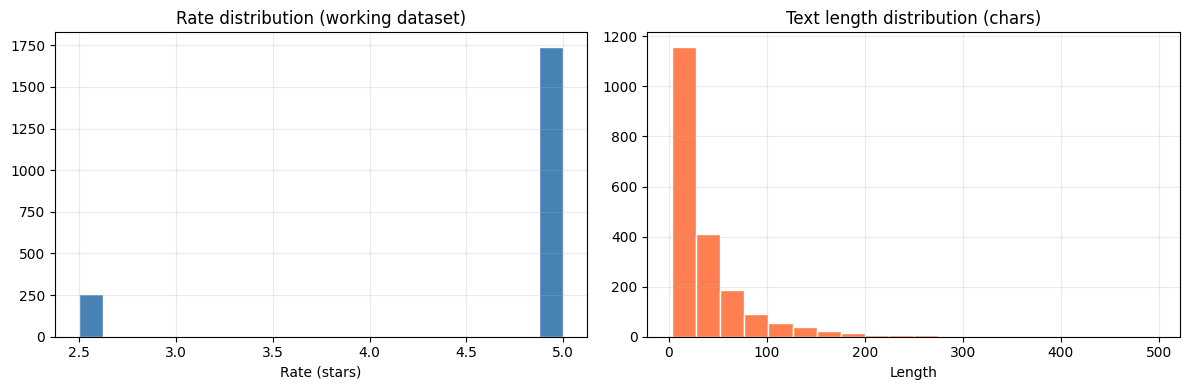

Example texts:
- بسیار با تجربه
- عالی بود
- تنگی کانال نخاع
- ریزش مو داشتم و رفع شد بسیار عالی هستند
- عالی بودن


In [ ]:
# ----------------------------
# Part 0.7 — Quick exploration (optional)
# ----------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_work["rate_num"].dropna().hist(bins=20, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Rate distribution (working dataset)")
axes[0].set_xlabel("Rate (stars)")

text_len = df_work["text_step04"].astype(str).str.len()
text_len.hist(bins=20, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Text length distribution (chars)")
axes[1].set_xlabel("Length")

plt.tight_layout()
plt.show()

print("Example texts:")
for t in df_work["text_step04"].sample(5, random_state=SEED).tolist():
    print("-", t[:120])

## Part 1 — Build a Labeled Sentiment Dataset

Models cannot learn sentiment without labeled examples.

In this part we will:
1. Define our sentiment label space (**-1 / 0 / +1**).
2. Create a small labeled dataset in a classroom-friendly way.
3. Save `train/dev/test` splits for the rest of the notebook.

Important note:
- The `rate` (stars) column is **not ground-truth sentiment**.
- We will use it only as a **weak signal** to bootstrap a labeled dataset.

### 1.1 Label space and quick guidelines

We use 3 labels:

- **+1 (Positive)**: clear satisfaction / recommendation
- **0 (Neutral)**: informational, unclear, or mixed sentiment
- **-1 (Negative)**: clear dissatisfaction (including service complaints)

Rules of thumb:
- Service complaints (wait time, secretary, cost, scheduling) count as **negative**
- Purely informational comments (e.g., "MRI written", "prescribed meds") are often **neutral**
- Mixed sentiment ("doctor great but secretary rude") → **neutral**

In [ ]:
df.columns

Index(['doctor_id', 'final_preprocessed_text', 'text_step04', 'rate', 'label',
       'date', 'tok_all_count', 'tok_nostop_count', 'is_placeholder_negative',
       'rate_num'],
      dtype='str')

In [ ]:
# ----------------------------
# Part 1.2 — Prepare text column for sentiment
# ----------------------------

# df_s = df_work.copy()

# # Sentiment input text
# df_s["text"] = df_s["text_step04"].astype(str).str.strip()


### 1.3 Why not random sampling?

If we randomly sample comments, most labels will be positive (high class imbalance).
That makes training and evaluation confusing in a classroom setting.

So we will build a **balanced bootstrapped dataset**:
- some **likely-positive** examples
- some **likely-negative** examples
- some **likely-neutral** examples

In Demo Mode we keep it small and fast.
In Full Mode we can increase the sample sizes.

In [ ]:
ss = "زشک حاذق متین انسان بسیار پزشک حاذق در عین حال متین و انسان"
tok = ss.split()
list(zip(tok, tok[1:]))

[('زشک', 'حاذق'),
 ('حاذق', 'متین'),
 ('متین', 'انسان'),
 ('انسان', 'بسیار'),
 ('بسیار', 'پزشک'),
 ('پزشک', 'حاذق'),
 ('حاذق', 'در'),
 ('در', 'عین'),
 ('عین', 'حال'),
 ('حال', 'متین'),
 ('متین', 'و'),
 ('و', 'انسان')]

In [ ]:
# ----------------------------
# Part 1.4 — Build a balanced candidate pool (weak labels)
# Token-based heuristics + stricter service-complaint detection
# ----------------------------

import re

df_s = df.copy()
df_s["text"] = df_s["text_step04"].astype(str).str.strip()

# Simple heuristic tokenization (ONLY for weak labeling)
KW_CLEAN_RE = re.compile(r"[^0-9A-Za-z\u0600-\u06FF]+")
def kw_tokens(text: str):
    t = str(text).lower().replace("\u200c", " ")
    t = KW_CLEAN_RE.sub(" ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t.split() if t else []

def kw_bigrams(toks):
    return list(zip(toks, toks[1:])) if len(toks) >= 2 else []


df_s["kw_toks"] = df_s["text"].apply(kw_tokens)
df_s["kw_bi"]   = df_s["kw_toks"].apply(kw_bigrams)
df_s["n_tokens"] = df_s["kw_toks"].apply(len)

MIN_TOKENS = 3
df_s["too_short"] = df_s["n_tokens"].lt(MIN_TOKENS)

def has_any_token(toks, token_set):
    return len(set(toks) & token_set) > 0

def has_any_phrase(bigrams, phrase_set):
    return len(set(bigrams) & phrase_set) > 0


In [ ]:
df.head(100)

,doctor_id,final_preprocessed_text,text_step04,rate,label,date,tok_all_count,tok_nostop_count,is_placeholder_negative,rate_num
0,100246,حاذق,بسیار حاذق,5.0,1,۱۴۰۳/۰۸/۰۴,2,1,False,5.0
1,100246,زگیل ناخن درمانم,زگیل زیر ناخن تحت درمانم,5.0,1,۱۴۰۰/۰۲/۰۶,5,3,False,5.0
2,100246,درود تشخیص درست خارش بدن ودرمان,درود تشخیص درست خارش بدن ودرمان عالی,5.0,1,۱۴۰۴/۰۹/۲۸,7,6,False,5.0
3,100246,دقت حوصله,بسیار با دقت و با حوصله,5.0,1,۱۴۰۴/۰۹/۲۷,5,2,False,5.0
4,100246,تشخیص ممنون,تشخیص ایشان خیلی خوب بود ممنون,5.0,1,۱۴۰۴/۰۵/۲۷,6,2,False,5.0
...,...,...,...,...,...,...,...,...,...,...
105,100246,بیماری پوستی گال داشتم داروهای بودش,بیماری پوستی گال داشتم داروهای ایشان خیلی عالی...,5.0,1,۱۴۰۳/۱۰/۰۸,9,6,False,5.0
106,100246,فعلا دارم درمان میشم راضی هستم,فعلا دارم درمان میشم راضی هستم,5.0,1,۱۴۰۳/۱۲/۲۰,6,6,False,5.0
108,100246,سلام صورتم پوسته پوسته توسط مادرم ایشون درمانج...,سلام من صورتم پوسته پوسته می‌شد که توسط مادرم ...,2.5,0,۱۴۰۰/۰۳/۲۳,18,10,False,2.5
109,100246,جوش می‌زدم الان جوشم کنترل,عالی جوش می‌زدم و الان جوشم کنترل شده,5.0,1,۱۴۰۳/۱۲/۲۱,7,5,False,5.0


In [ ]:
df_s

,doctor_id,final_preprocessed_text,text_step04,rate,label,date,tok_all_count,tok_nostop_count,is_placeholder_negative,rate_num,text,kw_toks,kw_bi,n_tokens,too_short
0,100246,حاذق,بسیار حاذق,5.0,1,۱۴۰۳/۰۸/۰۴,2,1,False,5.0,بسیار حاذق,"[بسیار, حاذق]","[(بسیار, حاذق)]",2,True
1,100246,زگیل ناخن درمانم,زگیل زیر ناخن تحت درمانم,5.0,1,۱۴۰۰/۰۲/۰۶,5,3,False,5.0,زگیل زیر ناخن تحت درمانم,"[زگیل, زیر, ناخن, تحت, درمانم]","[(زگیل, زیر), (زیر, ناخن), (ناخن, تحت), (تحت, ...",5,False
2,100246,درود تشخیص درست خارش بدن ودرمان,درود تشخیص درست خارش بدن ودرمان عالی,5.0,1,۱۴۰۴/۰۹/۲۸,7,6,False,5.0,درود تشخیص درست خارش بدن ودرمان عالی,"[درود, تشخیص, درست, خارش, بدن, ودرمان, عالی]","[(درود, تشخیص), (تشخیص, درست), (درست, خارش), (...",7,False
3,100246,دقت حوصله,بسیار با دقت و با حوصله,5.0,1,۱۴۰۴/۰۹/۲۷,5,2,False,5.0,بسیار با دقت و با حوصله,"[بسیار, با, دقت, و, با, حوصله]","[(بسیار, با), (با, دقت), (دقت, و), (و, با), (ب...",6,False
4,100246,تشخیص ممنون,تشخیص ایشان خیلی خوب بود ممنون,5.0,1,۱۴۰۴/۰۵/۲۷,6,2,False,5.0,تشخیص ایشان خیلی خوب بود ممنون,"[تشخیص, ایشان, خیلی, خوب, بود, ممنون]","[(تشخیص, ایشان), (ایشان, خیلی), (خیلی, خوب), (...",6,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66459,343423,جراحی خال درمان زگیل انجام دادم,بسیار عالی بودن جراحی خال و درمان زگیل انجام دادم,5.0,1,۱۴۰۴/۱۲/۰۱,9,6,False,5.0,بسیار عالی بودن جراحی خال و درمان زگیل انجام دادم,"[بسیار, عالی, بودن, جراحی, خال, و, درمان, زگیل...","[(بسیار, عالی), (عالی, بودن), (بودن, جراحی), (...",10,False
66460,343423,درمان زگیل پوستی,درمان زگیل پوستی,5.0,1,۱۴۰۴/۱۲/۰۳,3,3,False,5.0,درمان زگیل پوستی,"[درمان, زگیل, پوستی]","[(درمان, زگیل), (زگیل, پوستی)]",3,False
66461,343423,شدت ریزش مو داشتم ماه هفتاد درصد کاهش داشتم را...,به شدت ریزش مو داشتم بعد سه ماه هفتاد درصد کاه...,5.0,1,۱۴۰۴/۱۱/۲۸,19,15,False,5.0,به شدت ریزش مو داشتم بعد سه ماه هفتاد درصد کاه...,"[به, شدت, ریزش, مو, داشتم, بعد, سه, ماه, هفتاد...","[(به, شدت), (شدت, ریزش), (ریزش, مو), (مو, داشت...",22,False
66462,343423,درمان پسوریازیس انجام دادم دوسال شدم,درمان پسوریازیس انجام دادم بعد دوسال خوب شدم,5.0,1,۱۴۰۴/۱۱/۲۷,8,6,False,5.0,درمان پسوریازیس انجام دادم بعد دوسال خوب شدم,"[درمان, پسوریازیس, انجام, دادم, بعد, دوسال, خو...","[(درمان, پسوریازیس), (پسوریازیس, انجام), (انجا...",8,False


In [ ]:

# -------------------------
# -------------------------
POS_TOKENS = {"عالی","بهترین","محشر","حاذق","ماهر","کاربلد","دقیق","راضیم","ممنون","مرسی","سپاس","تشکر"}
POS_PHRASES = {
    ("فوق","العاده"),
    ("بی","نظیر"),
    ("تشخیص","دقیق"),
    ("نتیجه","گرفتم"),
    ("بهتر","شدم"),
    ("خوب","شدم"),
    ("خوش","برخورد"),
    ("با","حوصله"),
    ("حل","شد"),
    ("برطرف","شد"),
    ("رضایت","بخش"),
}

# -------------------------
# Strong negative cues (avoid ambiguous tokens like "تاخیر" alone)
# -------------------------
NEG_TOKENS = {"افتضاح","مزخرف","فاجعه","ناراضی","پشیمون","پشیمان","اشتباه","معطلی","انتظار","پولکی","گرون","گران"}
NEG_PHRASES = {
    ("بد","برخورد"),
    ("بی","ادب"),
    ("بی","احترام"),
    ("راضی","نیستم"),
    ("راضی","نبودم"),
    ("توصیه","نمی"),
    ("پیشنهاد","نمی"),
    ("دیگه","نمیرم"),
    ("نتیجه","نگرفتم"),
    ("اثر","نداشت"),
    ("فایده","نداشت"),
    ("بدتر","شدم"),
    ("هزینه","بالا"),
    ("تشخیص","اشتباه"),
    ("دارو","اشتباه"),
    ("حل","نشد"),
    ("حل","نشده"),
    ("فرقی","نکرد"),
    ("تغییر","نکرد"),
    ("بهتر","نشد"),
}

INFO_TOKENS = {"نسخه","دارو","آزمایش","سونو","سونگرافی","تصویربرداری","mri","ct","نوار","عمل","جراحی","لیزر","تزریق"}

# Soft positive cues for mixed detection
SOFT_POS_TOKENS = {"خوب","خوبه","مهربان","منصف","صبور","بااخلاق","خوشبرخورد","حوصله"}
SOFT_POS_PHRASES = {("خوب","بود"), ("خیلی","خوب")}

CONTRAST_TOKENS = {"ولی","اما","هرچند"}

# -------------------------
# Service complaint detection (STRICT): only clear complaint phrases
# This prevents false positives like: "no crowd (was not crowded)".
# -------------------------
SERVICE_COMPLAINT_PHRASES = {
    ("خیلی","شلوغ"),
    ("شلوغ","بود"),
    ("معطلی","زیاد"),
    ("انتظار","زیاد"),
    ("هزینه","بالا"),
    ("دسترسی","سخت"),
    ("تلفن","جواب"),
    ("منشی","بد"),
    ("نوبت","دیر"),
    ("نوبت","دهی"),
}

def strong_pos(row):
    return has_any_token(row["kw_toks"], POS_TOKENS) or has_any_phrase(row["kw_bi"], POS_PHRASES)

def strong_neg(row):
    return has_any_token(row["kw_toks"], NEG_TOKENS) or has_any_phrase(row["kw_bi"], NEG_PHRASES)

def info_hit(row):
    return has_any_token(row["kw_toks"], INFO_TOKENS)

def soft_pos(row):
    return has_any_token(row["kw_toks"], SOFT_POS_TOKENS) or has_any_phrase(row["kw_bi"], SOFT_POS_PHRASES)

def contrast_hit(row):
    return has_any_token(row["kw_toks"], CONTRAST_TOKENS)

def service_complaint(row):
    return has_any_phrase(row["kw_bi"], SERVICE_COMPLAINT_PHRASES)


df_s["has_pos_kw"]  = df_s.apply(strong_pos, axis=1)
df_s["has_neg_kw"]  = df_s.apply(strong_neg, axis=1)
df_s["has_info_kw"] = df_s.apply(info_hit, axis=1)
df_s["has_soft_pos_kw"] = df_s.apply(soft_pos, axis=1)
df_s["has_contrast"] = df_s.apply(contrast_hit, axis=1)
df_s["has_service_complaint"] = df_s.apply(service_complaint, axis=1)

# Mixed = (negative or service complaint) + (positive or soft positive) + contrast word
df_s["mixed_cue"] = (df_s["has_neg_kw"] | df_s["has_service_complaint"]) & (df_s["has_pos_kw"] | df_s["has_soft_pos_kw"]) & df_s["has_contrast"]

# Candidates
pos_cand = df_s[df_s["has_pos_kw"] & ~df_s["has_neg_kw"] & ~df_s["has_service_complaint"] & ~df_s["too_short"] & ~df_s["has_contrast"]].copy()

neg_cand = df_s[
    (df_s["has_neg_kw"] | df_s["has_service_complaint"] | df_s["rate_num"].le(1.8))
    & ~df_s["has_pos_kw"]
    & ~df_s["too_short"]
    & ~df_s["mixed_cue"]
].copy()

neu_cand = df_s[
    (df_s["mixed_cue"])
    | (df_s["has_info_kw"] & ~df_s["has_pos_kw"] & ~df_s["has_neg_kw"])
    | (df_s["too_short"] & ~df_s["has_pos_kw"] & ~df_s["has_neg_kw"])
    | (~df_s["has_pos_kw"] & ~df_s["has_neg_kw"])
].copy()

print("Candidate availability (before sampling):")
print("  pos_cand:", len(pos_cand))
print("  neg_cand:", len(neg_cand))
print("  neu_cand:", len(neu_cand))

# Targets
if MODE == "demo":
    N_POS, N_NEG, N_NEU = 250, 250, 250
else:
    N_POS, N_NEG, N_NEU = 3000, 3000, 3000

pos_pool = pos_cand.sample(n=min(N_POS, len(pos_cand)), random_state=SEED).copy()
neg_pool = neg_cand.sample(n=min(N_NEG, len(neg_cand)), random_state=SEED).copy()
neu_pool = neu_cand.sample(n=min(N_NEU, len(neu_cand)), random_state=SEED).copy()

pos_pool["weak_label"] = 1
neg_pool["weak_label"] = -1
neu_pool["weak_label"] = 0

pos_pool["label_source"] = "weak_pos"
neg_pool["label_source"] = "weak_neg"
neu_pool["label_source"] = "weak_neu"

pool = pd.concat([pos_pool, neg_pool, neu_pool], ignore_index=True)
pool = pool.drop_duplicates(subset=["text"]).reset_index(drop=True)
pool["item_id"] = [f"sent_{i:06d}" for i in range(len(pool))]

print("\nFinal candidate pool:")
print("  size:", len(pool))
print(pool["weak_label"].value_counts().sort_index())

print("\nSamples per class:")
for lbl in [-1, 0, 1]:
    ex = pool[pool["weak_label"] == lbl].sample(3, random_state=SEED)[["rate_num", "text"]]
    print(f"\nLabel {lbl}:")
    for r in ex.to_dict("records"):
        print(" -", f"(rate={r['rate_num']})", r["text"][:120])

pool[["item_id","doctor_id","rate_num","weak_label","label_source","text"]].head(10)

Candidate availability (before sampling):
  pos_cand: 17948
  neg_cand: 408
  neu_cand: 39180

Final candidate pool:
  size: 704
weak_label
-1    226
 0    230
 1    248
Name: count, dtype: int64

Samples per class:

Label -1:
 - (rate=2.5) زیادی معطلی داره کلا شلوغه و منشی‌ها خیلی زیادن و عامل بی نظمی هستن
 - (rate=2.5) یکبار ویزیت تلفنی شدم و از رفتار منشی‌اش راضی نبودم
 - (rate=2.5) مطب خیلی شلوغ بود ماهم شنیدیم کارش خوبه فعلا که تا mri گرفتن پیش رفتیم

Label 0:
 - (rate=5.0) دکتر بابایی جراح دست و کتف بنده بودن و از اون زمان من در خدمتشون بودم بو الان همم برای معاینه‌های دوره‌ای پیششون میرم
 - (rate=2.5) بد نیست
 - (rate=5.0) تنگی نخاع

Label 1:
 - (rate=2.5) برای مراقبت بارداری مراجعه کردم اولین بار بود پزشک با حوصله و مهربونی هستن وقت گذاشتن و وضعیتم توضیح دادن
 - (rate=5.0) عفونت گوش داشتم با تجویز داروهای خانم دکتر برطرف شد
 - (rate=5.0) بهترین دکتر است کارش حرف نداره همیشه 20 دست به کارش خوبه ازش راضیم


,item_id,doctor_id,rate_num,weak_label,label_source,text
0,sent_000000,295516,5.0,1,weak_pos,خیلی توانا و عالی
1,sent_000001,320341,5.0,1,weak_pos,دکتر بسیار دقیق و حاذقی هستند ن برای درد استخو...
2,sent_000002,325366,5.0,1,weak_pos,خوش‌برخورد اولین ویزیت بود
3,sent_000003,219108,5.0,1,weak_pos,نازایی آقایان عالی هستند
4,sent_000004,330854,5.0,1,weak_pos,بسیار دکتر با اخلاق و کاربلد هستن برای جراحی پ...
5,sent_000005,328601,5.0,1,weak_pos,من تحت نظر خانم دکتر بودم و باردار شدم سزارین ...
6,sent_000006,320761,5.0,1,weak_pos,عفونت گوش داشتم با تجویز داروهای خانم دکتر برط...
7,sent_000007,110120,5.0,1,weak_pos,دکتر بسیار بیار عالی با دانش و خوش برخوردی هستند
8,sent_000008,114194,5.0,1,weak_pos,بسیار خوش‌برخورد و با آرامش به صحبت‌های بیمار ...
9,sent_000009,314638,5.0,1,weak_pos,فوق العاده یک جلسه‌ای درمانم کردن


### 1.5 Optional: LLM labeling (batch mode)

Weak labels are useful, but noisy.

Optionally, we can ask an LLM to label a small subset of items.
To keep cost low:
- label only a limited number of items
- send many comments per request (batching)
- if API key is empty, skip this step and keep weak labels

In [ ]:
! pip install openai

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# ----------------------------
# Part 1.6 — LLM labeling (batched)
# ----------------------------

import json
import pandas as pd

# Hard-coded config (as requested)
USE_LLM  = True
API_KEY  = "sk-Zq0gCt5vWjMD9pSfOtrlmlZV0O11dFru1fycyh8BWPgB604B"                 # <-- put your key here
BASE_URL = "https://api.gapgpt.app/v1"     # <-- your proxy base URL
MODEL    = "gpt-4o-mini"

# Cost controls
LLM_MAX_ITEMS  = len(pool) if MODE == "demo" else 2000
BATCH_SIZE     = 30     # fewer requests; reduce to 30 if you get timeouts
TEXT_MAX_CHARS = 350    # reduce to 200 if timeouts happen

# Recommended: only label the weak -1 and 0 classes (saves money)
LLM_TARGET_WEAK_LABELS = [-1, 0 , 1]

# Build client
from openai import OpenAI
client = OpenAI(api_key=API_KEY, base_url=BASE_URL)

SYSTEM_PROMPT = """You are a professional Persian sentiment annotator.
Label each review:
1 = Positive, 0 = Neutral/Mixed/Informational, -1 = Negative.
Service complaints (wait time, secretary, scheduling, cost) are Negative.

Return ONLY a JSON array (no extra text).
Each item:
{"item_id":"...","label":-1|0|1}
"""

def parse_json_array(s: str):
    """Minimal robust parser: direct json or slice between [ ... ]."""
    s = (s or "").strip()
    try:
        obj = json.loads(s)
        if isinstance(obj, list):
            return obj
    except Exception:
        pass
    i, j = s.find("["), s.rfind("]")
    if i != -1 and j != -1 and j > i:
        obj = json.loads(s[i:j+1])
        if isinstance(obj, list):
            return obj
    raise ValueError("Could not parse a JSON array from the model output.")

def llm_label_batch(items):
    payload = [{"item_id": it["item_id"], "text": it["text"][:TEXT_MAX_CHARS]} for it in items]
    user_prompt = json.dumps(payload, ensure_ascii=False)

    resp = client.chat.completions.create(
        model=MODEL,
        temperature=0,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user_prompt},
        ],
        max_tokens=2000,
        timeout=90,
    )
    raw = resp.choices[0].message.content or ""
    return parse_json_array(raw)

# Select which rows we send to the LLM (keep this dataframe for QA)
to_label_df = pool[pool["weak_label"].isin(LLM_TARGET_WEAK_LABELS)].copy()
to_label_df = to_label_df.sample(frac=1.0, random_state=SEED).head(min(LLM_MAX_ITEMS, len(to_label_df)))

items = to_label_df[["item_id", "text"]].to_dict("records")
print(f"LLM labeling {len(items)} items in batches of {BATCH_SIZE}...")

all_rows = []
n_batches = (len(items) + BATCH_SIZE - 1) // BATCH_SIZE

for bi in range(n_batches):
    batch = items[bi*BATCH_SIZE : (bi+1)*BATCH_SIZE]
    out = llm_label_batch(batch)

    # Validate: keep only correct schema + correct ids + correct labels
    wanted_ids = {x["item_id"] for x in batch}
    kept_this_batch = 0

    for obj in out:
        if not isinstance(obj, dict):
            continue
        iid = str(obj.get("item_id", ""))
        lab = obj.get("label", None)
        if iid in wanted_ids and lab in (-1, 0, 1):
            all_rows.append({"item_id": iid, "label_llm": int(lab)})
            kept_this_batch += 1

    print(f"Batch {bi+1}/{n_batches} OK  (returned={len(out)} items, kept_in_batch={kept_this_batch}, kept_total={len(all_rows)})")

llm_labels_df = pd.DataFrame(all_rows).drop_duplicates("item_id").reset_index(drop=True)

print("\nLLM labeled items:", len(llm_labels_df))
if len(llm_labels_df):
    print(llm_labels_df["label_llm"].value_counts().sort_index())

LLM labeling 704 items in batches of 30...
Batch 1/24 OK  (returned=30 items, kept_in_batch=30, kept_total=30)
Batch 2/24 OK  (returned=30 items, kept_in_batch=30, kept_total=60)
Batch 3/24 OK  (returned=30 items, kept_in_batch=30, kept_total=90)
Batch 4/24 OK  (returned=30 items, kept_in_batch=30, kept_total=120)
Batch 5/24 OK  (returned=30 items, kept_in_batch=30, kept_total=150)
Batch 6/24 OK  (returned=30 items, kept_in_batch=30, kept_total=180)
Batch 7/24 OK  (returned=30 items, kept_in_batch=30, kept_total=210)
Batch 8/24 OK  (returned=30 items, kept_in_batch=30, kept_total=240)
Batch 9/24 OK  (returned=30 items, kept_in_batch=30, kept_total=270)
Batch 10/24 OK  (returned=30 items, kept_in_batch=30, kept_total=300)
Batch 11/24 OK  (returned=30 items, kept_in_batch=30, kept_total=330)
Batch 12/24 OK  (returned=30 items, kept_in_batch=30, kept_total=360)
Batch 13/24 OK  (returned=30 items, kept_in_batch=30, kept_total=390)
Batch 14/24 OK  (returned=29 items, kept_in_batch=29, kept_

### 1.6.1 QA: Validate LLM outputs (must pass before merging)

Before merging LLM labels into our dataset, we validate:

- schema correctness (`item_id`, `label_llm`)
- label range is valid (-1/0/1)
- no duplicate `item_id`
- 100% coverage (every requested item was labeled)
- no extra IDs returned by the LLM

In [ ]:
# ----------------------------
# QA — Validate LLM outputs (non-fatal for tiny missing counts)
# ----------------------------

required_cols = {"item_id", "label_llm"}
assert required_cols.issubset(set(llm_labels_df.columns)), "LLM output missing required columns."

assert llm_labels_df["item_id"].isna().sum() == 0, "NaN item_id in llm_labels_df."
assert llm_labels_df["item_id"].duplicated().sum() == 0, "Duplicate item_id in llm_labels_df."
assert llm_labels_df["label_llm"].isna().sum() == 0, "NaN label_llm in llm_labels_df."
assert set(llm_labels_df["label_llm"].unique()).issubset({-1, 0, 1}), "Invalid label outside {-1,0,1}."

requested_ids = set(to_label_df["item_id"])
got_ids = set(llm_labels_df["item_id"])
missing_ids = sorted(requested_ids - got_ids)
extra_ids = sorted(got_ids - requested_ids)

print("Requested items:", len(requested_ids))
print("LLM returned   :", len(got_ids))
print("Coverage       :", f"{len(got_ids)/max(1,len(requested_ids))*100:.2f}%")
print("Missing IDs    :", len(missing_ids))
print("Extra IDs      :", len(extra_ids))

if missing_ids:
    print("Missing (first 10):", missing_ids[:10])

# We allow a very small number of missing IDs, because merge will fall back to weak labels.
assert len(extra_ids) == 0, "LLM returned extra unknown IDs (should be 0)."
print("QA passed ✓ (missing IDs, if any, will fall back to weak labels in merge)")

Requested items: 704
LLM returned   : 703
Coverage       : 99.86%
Missing IDs    : 1
Extra IDs      : 0
Missing (first 10): ['sent_000552']
QA passed ✓ (missing IDs, if any, will fall back to weak labels in merge)


### 1.6.2 QA: Weak labels vs LLM labels (quick audit)

We compare weak labels to LLM labels to understand:
- how noisy our weak heuristics are
- what kinds of examples get corrected by the LLM

In [ ]:
# ----------------------------
# QA — Weak vs LLM audit
# ----------------------------

audit_df = to_label_df[["item_id", "weak_label", "text", "rate_num"]].merge(
    llm_labels_df, on="item_id", how="inner", validate="one_to_one"
)

audit_df["changed"] = (audit_df["weak_label"] != audit_df["label_llm"])

print("Disagreement rate:",
      f"{audit_df['changed'].mean()*100:.1f}%  ({audit_df['changed'].sum()}/{len(audit_df)})")

print("\nConfusion (weak → llm):")
print(pd.crosstab(audit_df["weak_label"], audit_df["label_llm"]))

# Show a few examples of flips (for teaching)
flips = audit_df[audit_df["changed"]].copy()

print("\nExamples: weak=-1 but llm=+1")
ex = flips[(flips["weak_label"] == -1) & (flips["label_llm"] == 1)].head(10)
for r in ex.to_dict("records"):
    print("-", r["text"][:160])

print("\nExamples: weak=0 but llm=-1")
ex = flips[(flips["weak_label"] == 0) & (flips["label_llm"] == -1)].head(10)
for r in ex.to_dict("records"):
    print("-", r["text"][:160])

Disagreement rate: 31.6%  (222/703)

Confusion (weak → llm):
label_llm    -1    0    1
weak_label               
-1          130   58   38
 0           13  105  111
 1            1    1  246

Examples: weak=-1 but llm=+1
- ایشون دکتر با دقت و خوش برخوردی هستند من براس چکاب خدمتشون میرم و بطور کامل راجع به بیماری و شرایط توضیح میدن و همینطور همه کارها در مطب با نظم و بدون معطلی زیا
- تشخیص درست داشتن خیلی دقیقاند مطب بهشتی خیلی شلوغ بود اما آخرین بار مطب ظفر رفتم سرتایم ویزیت شدم
- سرگیجه داشتم دکترباخلاق و حاذقی است معطلی نداشتم چند نفر از بستگان هم توسط ایشان معالجه شدند راضی بودند و دکتر ناصحی را به من معرفی کردند
- صورتم خیلی جوش می‌زد و مدت طولانی درمان‌های مختلف انجام دادم نتیجه نگرفتم الان تقریبا 4 ماهه تحت درمان خانم دکتر گنجه‌ای هستم و نه‌تنها جوش‌ها درمان شدن بلکه مش
- وااقعا دکتر خوبیه نه داروی گرون داد نه نسخه‌ی الکی تجویز کرد برای شکاف گوشه‌ی لبم رفتم پیشش
- مادرمن 2 سال جراحی اشتباه شده بودن و نمتونستن راه بروند و درد داشتن آقای دکتر میرزاصادقی پروتز گذاشتن والان درست بدون

### 1.6.3 Sanity check: LLM negatives with high star ratings

Stars are not perfect sentiment labels.
We quickly inspect a few cases where `rate` is high but the LLM predicts Negative.

In [ ]:
audit_llm = to_label_df[["item_id", "text", "rate_num", "weak_label"]].merge(
    llm_labels_df, on="item_id", how="inner", validate="one_to_one"
)

high_rate_neg = audit_llm[(audit_llm["rate_num"] >= 4.5) & (audit_llm["label_llm"] == -1)].head(10)

print("High-rate but LLM-negative examples:", len(high_rate_neg))
for r in high_rate_neg.to_dict("records"):
    print("-", f"(rate={r['rate_num']})", r["text"][:170])

High-rate but LLM-negative examples: 10
- (rate=5.0) دکتر خوبی بودند منتها مبلغ 50 هزار تومان زمان نوبت دهی آن لاین به ما برگردانده نشد ویزیت دکتر 600 بود برای ما شد 650
- (rate=5.0) بسیار دکتر دقیقی هستن ولی خیلی شلوغن و معطلی زیاد داره مطبشون
- (rate=5.0) دکتر بسیار متخصص و کاربلدی هستند تنها مشکلم وقت چند ساعته و طولانی انتظار در مطب علیرغم داشتن وقت قبلی هست
- (rate=5.0) دکتر محترم و خوش برخوردی بودن من برای روتین‌های پوستی رفتم و اصلا راضی نیستم صورتم لک شده
- (rate=5.0) تشخیص درست و به موقع جراحی مچ پا سالن انتظار تهویه مطبوع نداشت تو فصل گرما اذیت شدیم
- (rate=5.0) هم تشخیص هم رفتار فقط زمان معطلی زیاد بود
- (rate=5.0) دکتر بسیار باسواد و عاالی بودن فقط تایم انتظار 3 ساعت بود که ناراحت‌کننده است
- (rate=5.0) با سلام بسیار دکتر باسواد و دقیقی می‌باشد ولی نوبت دهی به شدت ضعیف و حیرانی مریض بالا می‌باشد
- (rate=5.0) دکتر خوبی هستند و بسیار با اخلاق فقط به دلیل زیاد بودن تعداد بیماران مدت زمان انتظار در مطب خیلی زیاد است
- (rate=5.0) بادقت به حرف‌های بیمار گوش می‌دهند ولی به شدت مطب

### 1.7 Merge labels (LLM overrides weak labels)

We now create the final label for each item:

- If an LLM label exists → use it
- Otherwise → fall back to the weak label

We keep both weak and LLM labels for auditability.

In [ ]:
# ----------------------------
# Part 1.7 — Merge labels (LLM overrides weak)
# ----------------------------

df_labeled = pool[["item_id", "doctor_id", "rate_num", "text", "weak_label", "label_source"]].copy()

df_labeled = df_labeled.merge(
    llm_labels_df,  # columns: item_id, label_llm
    on="item_id",
    how="left",
    validate="one_to_one",
)

# Final label
df_labeled["label_int"] = df_labeled["label_llm"].fillna(df_labeled["weak_label"]).astype(int)

# Track label source
df_labeled["label_source"] = np.where(df_labeled["label_llm"].notna(), "llm", df_labeled["label_source"])

# Final sanity checks
assert df_labeled["label_int"].isin([-1, 0, 1]).all()
assert df_labeled["label_int"].isna().sum() == 0

print("Final label distribution:")
print(df_labeled["label_int"].value_counts().sort_index())

print("\nLabel source distribution:")
print(df_labeled["label_source"].value_counts())

df_labeled.head(10)

Final label distribution:
label_int
-1    144
 0    165
 1    395
Name: count, dtype: int64

Label source distribution:
label_source
llm         703
weak_neu      1
Name: count, dtype: int64


,item_id,doctor_id,rate_num,text,weak_label,label_source,label_llm,label_int
0,sent_000000,121861,5.0,دکتر کاربلد و دقیق و دلسوز هستند و پیش ایشون ن...,1,llm,1.0,1
1,sent_000001,227381,5.0,ایشان بسیار حاذق می‌باشند سال 95 به همراه دکتر...,1,llm,1.0,1
2,sent_000002,253573,5.0,حاذق و خوش‌رو,1,llm,1.0,1
3,sent_000003,114729,5.0,دکتر بسیار خوش‌اخلاق ارام و با حوصله هستند و ر...,1,llm,1.0,1
4,sent_000004,219108,5.0,فوق‌العاده مجرب و بااخلاق هستند,1,llm,1.0,1
5,sent_000005,277071,5.0,مشکلاتمونو داشتم دست ایشون درد نکنه خیلی زود ج...,1,llm,1.0,1
6,sent_000006,115698,5.0,بسیار عالی منتها به علت کرونا درمان کامل نبود,1,llm,0.0,0
7,sent_000007,207435,5.0,نتیجه بسیار عالی,1,llm,1.0,1
8,sent_000008,188603,5.0,پزشک بسیار حاذق و با توجه و دقت فراوان نسبت به...,1,llm,1.0,1
9,sent_000009,127062,5.0,دکتر خوب با رفتار مناسب و تشخیص عالی,1,llm,1.0,1


In [ ]:
# ----------------------------
# Optional: quick inspection
# ----------------------------

for lbl in [-1, 0, 1]:
    print(f"\nExamples for final label {lbl}:")
    ex = df_labeled[df_labeled["label_int"] == lbl].sample(5, random_state=SEED)[["rate_num", "label_source", "text"]]
    for r in ex.to_dict("records"):
        print("-", f"(rate={r['rate_num']}, src={r['label_source']})", r["text"][:160])


Examples for final label -1:
- (rate=2.5, src=llm) مطب بسیار شلوغه نحوه نوبت دهی کاملا غلط هستش خانم‌های باردار هم کنار افراد معمولی بابد 5 ساعت منتظر نوبتشون بشن
- (rate=2.5, src=llm) بیشتر از ظرفیت پذیرش می‌کنند و معطلی بسیار زیاده
- (rate=2.5, src=llm) فعلا تحت درمان 4 ماهه نتیجه نگرفتم هنوز
- (rate=5.0, src=llm) دکتر بسیار حاذقی هستن فقط زمان انتظار ویزیت بیش از اندازه خسته‌کننده است
- (rate=2.5, src=llm) مشکل شنوایی داشتم ولی نتیجه نگرفتم در حد ویزیت 135 تومن نیست

Examples for final label 0:
- (rate=5.0, src=llm) عمل سینوزیت
- (rate=5.0, src=llm) ویزیت شدم و نوبت عمل
- (rate=2.5, src=llm) نظری ندارم
- (rate=2.5, src=llm) کمردرد فعلا نتیجه نگرفتم یک‌بار رفتم
- (rate=5.0, src=llm) عمل پا

Examples for final label 1:
- (rate=5.0, src=llm) دیسک کمر نتیجه عالی و با دوبار ویزیت کاملا خوب شدم
- (rate=5.0, src=llm) تشخیص درست و درمان خوب
- (rate=5.0, src=llm) سلام من مشکل اگزمای پوستی پشت پلک داشتم قبلا پیش چندتا دکتر رفتم ولی اصلا نتیجه نگرفتم اقای دکتر با تبحری که دارن تونستن با یک نس

### 1.8 Save dataset artifacts

We save the main artifact produced by this notebook:

- `labeled_dataset.csv` — the full labeled dataset (one row per comment)
  - includes `label_int` (final label)
  - includes `label_source` (llm vs weak fallback)
  - includes `doctor_id` for leakage-safe splitting

These files are used by the rest of this notebook (model training).

In [ ]:
df_labeled = pool[["doctor_id", "rate_num", "text", "weak_label", ]].copy()
df_labeled

,doctor_id,rate_num,text,weak_label
0,295516,5.0,خیلی توانا و عالی,1
1,320341,5.0,دکتر بسیار دقیق و حاذقی هستند ن برای درد استخو...,1
2,325366,5.0,خوش‌برخورد اولین ویزیت بود,1
3,219108,5.0,نازایی آقایان عالی هستند,1
4,330854,5.0,بسیار دکتر با اخلاق و کاربلد هستن برای جراحی پ...,1
...,...,...,...,...
699,105809,2.5,ویزیت دخترم برای گرفتگی گوش,0
700,115698,5.0,مراجعه‌کننده جدید هستم طول درمانم تمام نشده ام...,0
701,211644,5.0,لرزش شدیددست تحت درمان,0
702,102091,2.5,سلام قرمزی و لک روی پوستم بود نسبتا بهترشده ول...,0


In [ ]:
# ----------------------------
# Part 1.8 — Save labeled dataset
# ----------------------------

# Basic sanity checks (keep it simple but safe)
assert "weak_label" in df_labeled.columns
assert df_labeled["weak_label"].isin([-1, 0, 1]).all()

labeled_path = OUT_DIR / "labeled_dataset.csv"
df_labeled.to_csv(labeled_path, index=False, encoding="utf-8-sig")

print("Saved:", labeled_path)
print("Rows :", len(df_labeled))
print("\nLabel distribution:")
print(df_labeled["weak_label"].value_counts().sort_index())



Saved: processed_data/notebook04_sentiment/labeled_dataset.csv
Rows : 704

Label distribution:
weak_label
-1    226
 0    230
 1    248
Name: count, dtype: int64


### 1.9 Train/Dev/Test split (grouped by doctor_id)

**Hidden leakage problem:**
If comments from the same doctor appear in both train and test, models can memorize doctor-specific patterns.
That inflates test scores and does not generalize to unseen doctors.

So we split using **GroupShuffleSplit**:
- each `doctor_id` appears in exactly one split

In [ ]:
# ----------------------------
# Part 1.9 — Grouped Train/Dev/Test split
# ----------------------------

from sklearn.model_selection import GroupShuffleSplit

TEST_SIZE = 0.20
DEV_SIZE_FROM_TRAIN = 0.20  # dev is 20% of the remaining train split

# 1) split out test
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
train_idx, test_idx = next(gss.split(df_labeled, df_labeled["weak_label"], groups=df_labeled["doctor_id"]))

train_full = df_labeled.iloc[train_idx].copy().reset_index(drop=True)
test_df    = df_labeled.iloc[test_idx].copy().reset_index(drop=True)

# 2) split train_full into train + dev
gss2 = GroupShuffleSplit(n_splits=1, test_size=DEV_SIZE_FROM_TRAIN, random_state=SEED)
train_idx2, dev_idx = next(gss2.split(train_full, train_full["weak_label"], groups=train_full["doctor_id"]))

train_df = train_full.iloc[train_idx2].copy().reset_index(drop=True)
dev_df   = train_full.iloc[dev_idx].copy().reset_index(drop=True)

# Leakage checks (must be zero)
train_docs = set(train_df["doctor_id"])
dev_docs   = set(dev_df["doctor_id"])
test_docs  = set(test_df["doctor_id"])

assert train_docs.isdisjoint(dev_docs)
assert train_docs.isdisjoint(test_docs)
assert dev_docs.isdisjoint(test_docs)

print("Split sizes (rows):")
print(f"  train: {len(train_df):>4}")
print(f"  dev  : {len(dev_df):>4}")
print(f"  test : {len(test_df):>4}")

print("\nSplit sizes (unique doctors):")
print(f"  train doctors: {train_df['doctor_id'].nunique():>4}")
print(f"  dev doctors  : {dev_df['doctor_id'].nunique():>4}")
print(f"  test doctors : {test_df['doctor_id'].nunique():>4}")

print("\nTrain label distribution:")
print(train_df["weak_label"].value_counts().sort_index())

print("\nDev label distribution:")
print(dev_df["weak_label"].value_counts().sort_index())

print("\nTest label distribution:")
print(test_df["weak_label"].value_counts().sort_index())

Split sizes (rows):
  train:  461
  dev  :  113
  test :  130

Split sizes (unique doctors):
  train doctors:  208
  dev doctors  :   52
  test doctors :   65

Train label distribution:
weak_label
-1    158
 0    145
 1    158
Name: count, dtype: int64

Dev label distribution:
weak_label
-1    29
 0    38
 1    46
Name: count, dtype: int64

Test label distribution:
weak_label
-1    39
 0    47
 1    44
Name: count, dtype: int64


### 1.10 Save splits

We save:
- `train.csv`
- `dev.csv`
- `test.csv`

These will be used in Part 2 for model training and evaluation.

In [ ]:
# ----------------------------
# Part 1.10 — Save split CSVs
# ----------------------------

train_path = OUT_DIR / "train.csv"
dev_path   = OUT_DIR / "dev.csv"
test_path  = OUT_DIR / "test.csv"

train_df.to_csv(train_path, index=False, encoding="utf-8-sig")
dev_df.to_csv(dev_path, index=False, encoding="utf-8-sig")
test_df.to_csv(test_path, index=False, encoding="utf-8-sig")

print("Saved splits:")
print("-", train_path)
print("-", dev_path)
print("-", test_path)

Saved splits:
- processed_data/notebook04_sentiment/train.csv
- processed_data/notebook04_sentiment/dev.csv
- processed_data/notebook04_sentiment/test.csv


## Part 2 — Train Models (Classical → Neural → Transformers)

In Part 1, we created a labeled dataset and saved train/dev/test splits.

In this part we will train multiple sentiment models on the same splits:

1) **Classical baseline:** TF‑IDF → sklearn MLP  
2) **Neural model:** TF‑IDF → PyTorch MLP  
3) **Transformer:** ParsBERT fine-tuning

We start with the classical baseline because it is:
- fast
- easy to interpret
- a strong reference point

### 2.1 Load train/dev/test splits

We load the CSV files produced in Part 1:
- `train.csv`
- `dev.csv`
- `test.csv`

We will use:
- `text` as input
- `label_int` as the target

In [ ]:
# ----------------------------
# Part 2.1 — Load splits from disk
# ----------------------------

import joblib
from pathlib import Path

train_df = pd.read_csv(OUT_DIR / "train.csv", keep_default_na=False)
dev_df   = pd.read_csv(OUT_DIR / "dev.csv", keep_default_na=False)
test_df  = pd.read_csv(OUT_DIR / "test.csv", keep_default_na=False)

for d in [train_df, dev_df, test_df]:
    d["doctor_id"] = d["doctor_id"].astype(str)
    d["text"] = d["text"].astype(str)
    d["weak_label"] = pd.to_numeric(d["weak_label"], errors="coerce").astype(int)

print("Split sizes:")
print("  train:", len(train_df), " | doctors:", train_df["doctor_id"].nunique())
print("  dev  :", len(dev_df),   " | doctors:", dev_df["doctor_id"].nunique())
print("  test :", len(test_df),  " | doctors:", test_df["doctor_id"].nunique())

print("\nTrain label distribution:")
print(train_df["weak_label"].value_counts().sort_index())

Split sizes:
  train: 461  | doctors: 208
  dev  : 113  | doctors: 52
  test : 130  | doctors: 65

Train label distribution:
weak_label
-1    158
 0    145
 1    158
Name: count, dtype: int64


### 2.3 TF‑IDF features

We represent each comment as a TF‑IDF vector.

Why TF‑IDF?
- It turns text into numbers (a sparse vector).
- It is fast and surprisingly strong as a baseline.

We also include bigrams (1,2) to capture phrases like:
- "راضی نیستم"
- "بد برخورد"

In [ ]:
# ----------------------------
# Part 2.3 — Build TF‑IDF vectors
# ----------------------------

from sklearn.feature_extraction.text import TfidfVectorizer

def simple_preprocess(s: str) -> str:
    # lightweight normalization (keep it teachable)
    # - remove ZWNJ
    # - lowercase (helps latin tokens like MRI/CT)
    return str(s).replace("\u200c", " ").lower().strip()

vec = TfidfVectorizer(
    preprocessor=simple_preprocess,
    tokenizer=str.split,
    token_pattern=None,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    max_features=60000,
    sublinear_tf=True,
    norm="l2",
)
BALANCE_TRAIN = False
if not(BALANCE_TRAIN):
    train_used = train_df.copy()
X_train = vec.fit_transform(train_used["text"].tolist())
X_dev   = vec.transform(dev_df["text"].tolist())
X_test  = vec.transform(test_df["text"].tolist())

y_train = train_used["weak_label"].values
y_dev   = dev_df["weak_label"].values
y_test  = test_df["weak_label"].values

print("TF-IDF shapes:")
print("  X_train:", X_train.shape)
print("  X_dev  :", X_dev.shape)
print("  X_test :", X_test.shape)
print("Vocabulary size:", len(vec.vocabulary_))

TF-IDF shapes:
  X_train: (461, 1028)
  X_dev  : (113, 1028)
  X_test : (130, 1028)
Vocabulary size: 1028


### 2.4 Baseline model: sklearn MLP

We train a simple Multi-Layer Perceptron (MLP) classifier on TF‑IDF features.

Notes:
- This is a baseline. We do **not** run grid search.
- We use early stopping to avoid overfitting.

In [ ]:
# ----------------------------
# Part 2.4 — Train sklearn MLP baseline
# ----------------------------

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 64),
    activation="relu",
    alpha=1e-4,
    batch_size=64,
    learning_rate_init=1e-3,
    max_iter=60,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=5,
    random_state=SEED,
    verbose=False,
)

mlp.fit(X_train, y_train)
print("Training done.")
print("Iterations:", mlp.n_iter_)

Training done.
Iterations: 15


### 2.5 Evaluation

We report:
- Accuracy
- Macro-F1 (important for imbalanced classes)
- Confusion matrix


DEV
Accuracy : 0.7965
Macro-F1 : 0.7888

              precision    recall  f1-score   support

    Negative     0.8000    0.8276    0.8136        29
     Neutral     0.7742    0.6316    0.6957        38
    Positive     0.8077    0.9130    0.8571        46

    accuracy                         0.7965       113
   macro avg     0.7940    0.7907    0.7888       113
weighted avg     0.7945    0.7965    0.7917       113


TEST
Accuracy : 0.8385
Macro-F1 : 0.8369

              precision    recall  f1-score   support

    Negative     0.8293    0.8718    0.8500        39
     Neutral     0.8919    0.7021    0.7857        47
    Positive     0.8077    0.9545    0.8750        44

    accuracy                         0.8385       130
   macro avg     0.8430    0.8428    0.8369       130
weighted avg     0.8446    0.8385    0.8352       130



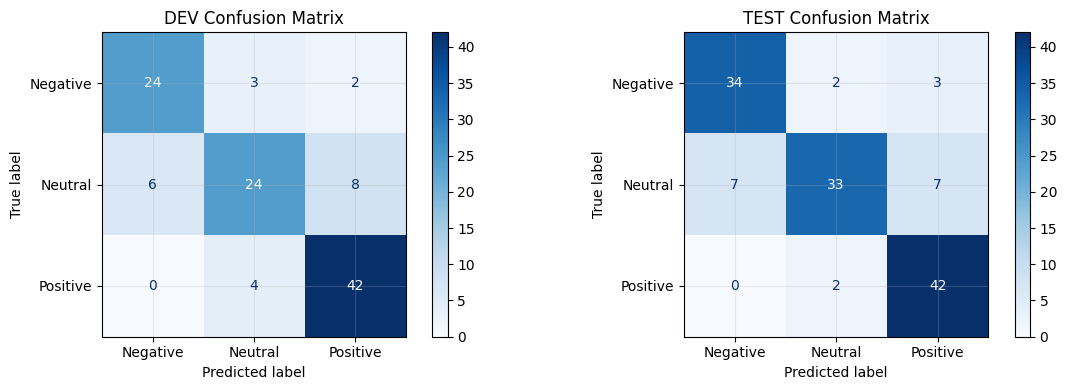

In [ ]:
# ----------------------------
# Part 2.5 — Evaluate on dev/test
# ----------------------------

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, ConfusionMatrixDisplay

LABELS = [-1, 0, 1]
LABEL_NAMES = ["Negative", "Neutral", "Positive"]

def evaluate_split(name, X, y_true):
    y_pred = mlp.predict(X)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")

    print("\n" + "="*60)
    print(f"{name}")
    print("="*60)
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro-F1 : {f1m:.4f}\n")
    print(classification_report(y_true, y_pred, labels=LABELS, target_names=LABEL_NAMES, digits=4, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    return y_pred, cm

dev_pred, dev_cm = evaluate_split("DEV", X_dev, y_dev)
test_pred, test_cm = evaluate_split("TEST", X_test, y_test)

# Plot confusion matrices (normalized)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(dev_cm, display_labels=LABEL_NAMES).plot(ax=axes[0], cmap="Blues", values_format="d")
axes[0].set_title("DEV Confusion Matrix")

ConfusionMatrixDisplay(test_cm, display_labels=LABEL_NAMES).plot(ax=axes[1], cmap="Blues", values_format="d")
axes[1].set_title("TEST Confusion Matrix")

plt.tight_layout()
plt.show()

### 2.6 Save the baseline model

We save:
- the TF‑IDF vectorizer
- the trained MLP model

This allows us to reuse the baseline later (and compare against BERT).

In [ ]:
# ----------------------------
# Part 2.6 — Save baseline model
# ----------------------------

baseline_path = MODEL_DIR / "tfidf_mlp_sklearn.joblib"

joblib.dump(
    {
        "vectorizer": vec,
        "model": mlp,
        "labels": LABELS,
        "label_names": LABEL_NAMES,
        "meta": {
            "mode": MODE,
            "balanced_train": BALANCE_TRAIN,
            "train_size": int(len(train_used)),
            "dev_size": int(len(dev_df)),
            "test_size": int(len(test_df)),
            "test_macro_f1": float(f1_score(y_test, test_pred, average="macro")),
        },
    },
    baseline_path,
    compress=3,
)

print("Saved:", baseline_path)
print("File size (MB):", baseline_path.stat().st_size / 1024 / 1024)

Saved: models/notebook04_sentiment/tfidf_mlp_sklearn.joblib
File size (MB): 6.1994829177856445
